In [44]:
from ISLP import load_data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
Auto = load_data('Auto')
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


# AUTO DATASET ANALYSIS
## REMOVING MISSING VALUES

In [3]:
Auto.dropna()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


In [4]:
Auto.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
dtype: int64

## a) Quantitative & Qualitative Predictors

In [5]:
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


## b) The range of each quantitave predictor

In [9]:
quantitative = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]
quantitative

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'year']

In [17]:
Auto[quantitative].agg(["min", "max"])

,mpg,cylinders,displacement,horsepower,weight,acceleration,year
min,9.0,3,68.0,46,1613,8.0,70
max,46.6,8,455.0,230,5140,24.8,82


In [14]:
Auto[quantitative].max() - Auto[quantitative].min()

mpg               37.6
cylinders          5.0
displacement     387.0
horsepower       184.0
weight          3527.0
acceleration      16.8
year              12.0
dtype: float64

##  C) Mean and Sd for each quantitative predictor

In [20]:
Auto[quantitative].agg(["mean", "std"])

,mpg,cylinders,displacement,horsepower,weight,acceleration,year
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737


## d) Removing 10th through 85th observations

In [23]:
Auto_subset = Auto.drop(Auto.index[9:85])


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
chevrolet malibu,13.0,8,350.0,145,3988,13.0,73,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


## Range, Mean, and Standard deviation of the subset

In [26]:
Auto_subset[quantitative].agg(["min","max", "mean","std"])

,mpg,cylinders,displacement,horsepower,weight,acceleration,year
min,11.000000,3.000000,68.000000,46.000000,1755.000000,9.500000,70.000000
max,46.600000,8.000000,455.000000,230.000000,4952.000000,24.600000,82.000000
mean,25.041637,5.274021,179.373665,98.715302,2881.505338,15.738790,77.508897
std,7.912874,1.632155,95.512897,33.822711,792.548494,2.570191,2.989403


## e) Scatterplot matrix

NameError: name 'plt' is not defined

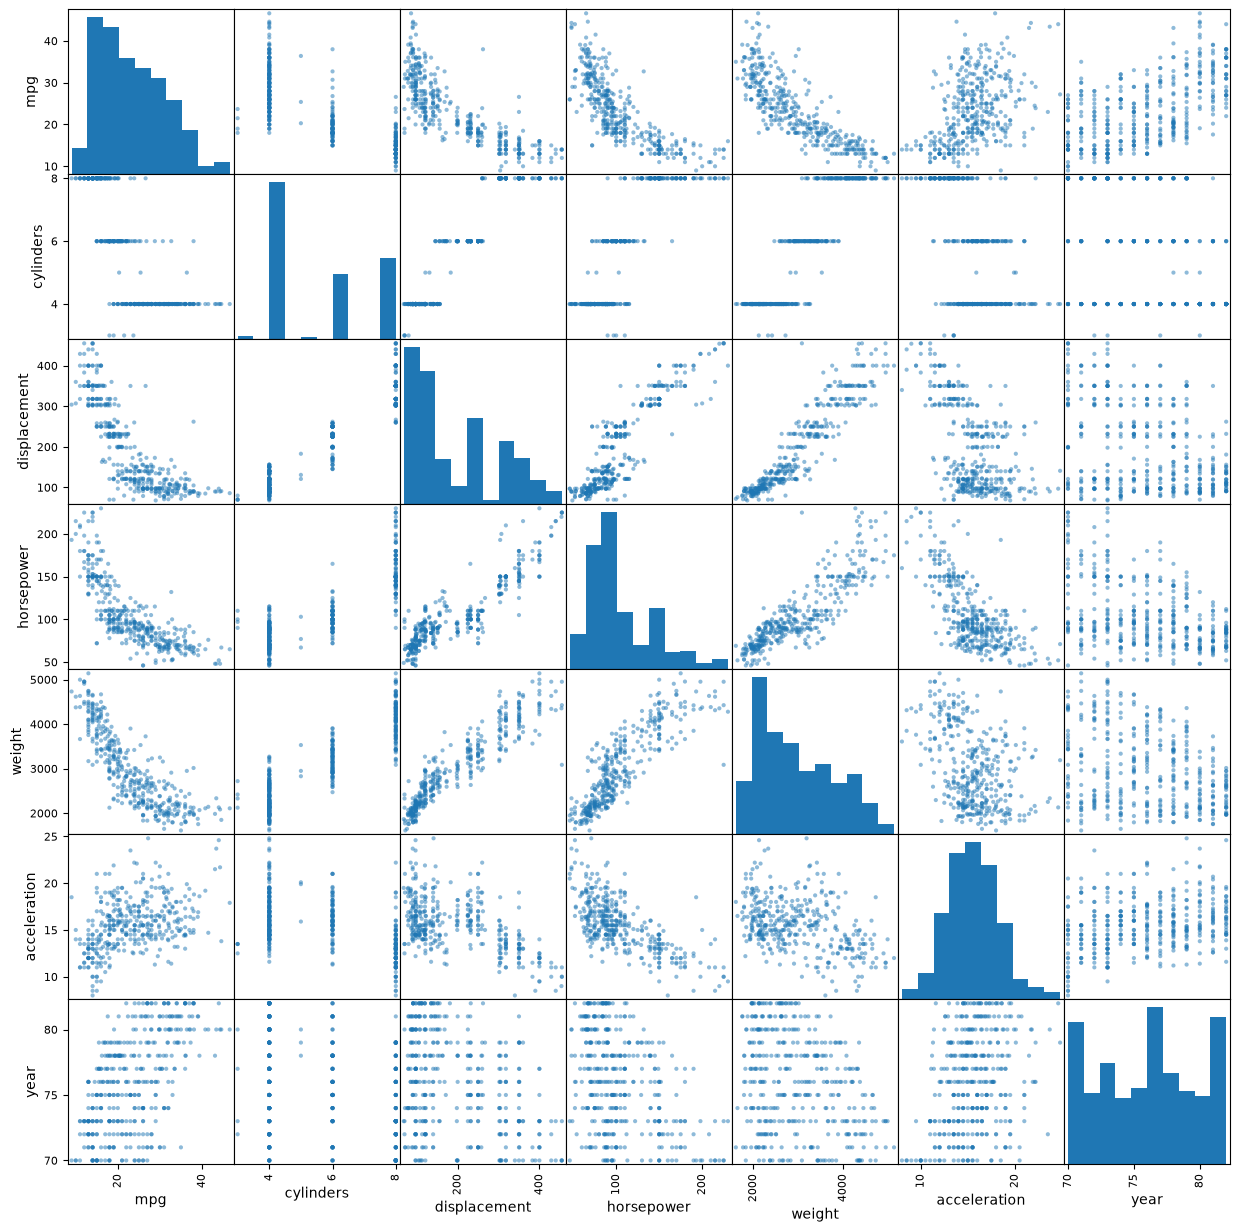

In [33]:
pd.plotting.scatter_matrix(
    Auto[quantitative],
    figsize=(15, 15)
)

plt.show()

## Mpg vs Weight

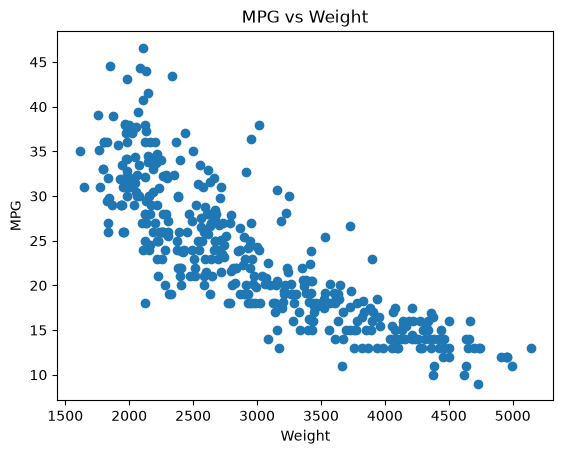

In [38]:
plt.scatter(Auto["weight"], Auto["mpg"])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("MPG vs Weight")
plt.show()

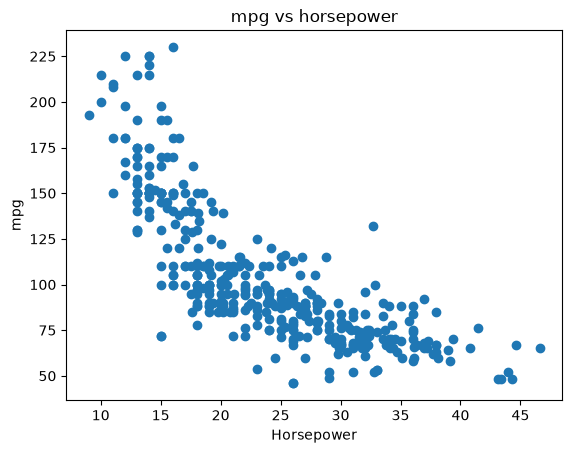

In [39]:
plt.scatter(Auto["mpg"], Auto["horsepower"])
plt.xlabel("Horsepower")
plt.ylabel("mpg")
plt.title("mpg vs horsepower")
plt.show()

## MPG vs Displacement

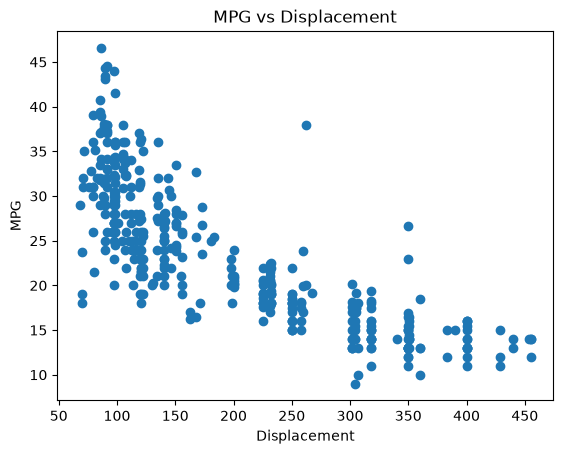

In [40]:
plt.scatter(Auto["displacement"], Auto["mpg"])
plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("MPG vs Displacement")
plt.show()

## mpg vs year

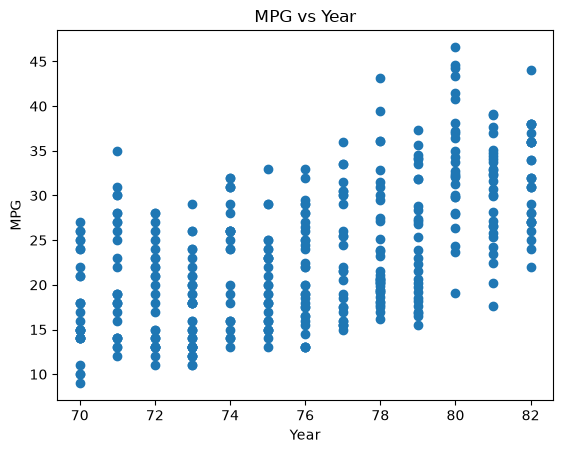

In [41]:
plt.scatter(Auto["year"], Auto["mpg"])
plt.xlabel("Year")
plt.ylabel("MPG")
plt.title("MPG vs Year")
plt.show()

#### The scatterplots show several clear relationships among the predictors. Weight, horsepower, displacement, and cylinders have generally negative relationships with mpg. This means that heavier vehicles and vehicles with larger engines or more horsepower tend to have lower fuel efficiency. In contrast, year has a positive relationship with mpg, indicating that newer vehicles tend to have better fuel efficiency. The plots also suggest that some of the predictors, such as horsepower, displacement, weight, and cylinders, are strongly related to each other.

## f) Predicint MPG

#### Yes. The scatterplots suggest that several of the other variables could be useful in predicting mpg. In particular, weight, horsepower, and displacement show strong negative relationships with mpg, while year shows a positive relationship. Therefore, these variables are likely to be useful predictors of gas mileage. The relationships are sufficiently clear in the scatterplots to suggest that a regression model using these variables could predict mpg reasonably well.

## 4) b) Example in which the coefficient estimates for the regression of Y onto X and hte regression of X onto Y are different

In [45]:
# Make the results reproducible
np.random.seed(1)

# Number of observations
n = 100

# Generate X and Y
X = np.random.normal(size=n)
Y = 2 * X + np.random.normal(size=n)

# Regression of Y onto X WITHOUT an intercept
model_Y_X = sm.OLS(Y, X).fit()

# Regression of X onto Y WITHOUT an intercept
model_X_Y = sm.OLS(X, Y).fit()

# Print the coefficients
print("Coefficient for Y onto X:", model_Y_X.params[0])
print("Coefficient for X onto Y:", model_X_Y.params[0])

Coefficient for Y onto X: 2.1067416889591146
Coefficient for X onto Y: 0.3789044229072016


### Checking if two sums are different

In [46]:
print("Sum of X²:", np.sum(X**2))
print("Sum of Y²:", np.sum(Y**2))

Sum of X²: 78.71718048502926
Sum of Y²: 437.67439950350075


## 4) c) When Coefficient estimates for the regression of Y onto X and the regression of X onto Y 

In [47]:
# Make the results reproducible
np.random.seed(1)

# Number of observations
n = 100

# Generate X
X = np.random.normal(size=n)

# Y contains the same values as X, but shuffled
Y = np.random.permutation(X)

# Regression of Y onto X WITHOUT an intercept
model_Y_X = sm.OLS(Y, X).fit()

# Regression of X onto Y WITHOUT an intercept
model_X_Y = sm.OLS(X, Y).fit()

# Print the coefficients
print("Coefficient for Y onto X:", model_Y_X.params[0])
print("Coefficient for X onto Y:", model_X_Y.params[0])

# Check the sums of squares
print("Sum of X²:", np.sum(X**2))
print("Sum of Y²:", np.sum(Y**2))

Coefficient for Y onto X: 0.21456723150810011
Coefficient for X onto Y: 0.2145672315081001
Sum of X²: 78.71718048502926
Sum of Y²: 78.71718048502927
